# Mandarin Tone Discrimination Task Analysis

In [1]:
import importlib
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchaudio
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from tqdm.auto import tqdm

import sys
sys.path.append('../')

from lightning_scripts.utils.model_build_utils import get_model
from lightning_scripts.byola_lightning_module import BYOLAModule
from lightning_scripts.tone_perfect_triplet_dataset import TonePerfectDataset

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    normalize_model_name,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
    plot_grouped_bars,
)

torch.set_float32_matmul_precision("medium")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

%matplotlib inline

/mnt/ceph/users/igriffith/projects/cochdnn/byol-a/byol_a/common.py:31: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("sox_io")


## Dataset Setup

In [2]:
model_sr = 20_000

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Helper Functions

In [3]:
from typing import Dict


def encode_audio(model, audio_batch: torch.Tensor) -> torch.Tensor:
    """Encode audio batch to embeddings."""
    model.eval()
    with torch.no_grad():
        z = model(audio_batch)
        if z.ndim > 2:
            z = z.flatten(start_dim=1)
    return z



def distance_metrics_on_triplet(model, clips: Dict[str, torch.Tensor], sr: int) -> Dict[str, float]:
    """Compute embedding-space distance metrics for (anchor, positive, negative)."""
    waves: Dict[str, torch.Tensor] = {}
    for k, v in clips.items():
        w = v
        # BYOL-A wrapper handles its own resampling; this notebook provides 20kHz by default
        if isinstance(model, BYOLAModule):
            w = torchaudio.functional.resample(w.unsqueeze(0), sr, 16_000).squeeze(0)
        waves[k] = w.to(DEVICE)

    # Encode each example separately -- do not pair batch
    if isinstance(model, BYOLAModule):
        anchor_batch = waves["anchor"].unsqueeze(0)
        positive_batch = waves["positive"].unsqueeze(0)
        negative_batch = waves["negative"].unsqueeze(0)
    else:
        # robustness / cochdnn models expect [B, C, T]
        anchor_batch = waves["anchor"].unsqueeze(0).unsqueeze(1)
        positive_batch = waves["positive"].unsqueeze(0).unsqueeze(1)
        negative_batch = waves["negative"].unsqueeze(0).unsqueeze(1)

    z_anchor = encode_audio(model, anchor_batch)
    z_pos = encode_audio(model, positive_batch)
    z_neg = encode_audio(model, negative_batch)

    # L2
    pos_l2 = torch.norm(z_anchor - z_pos, p=2).item()
    neg_l2 = torch.norm(z_anchor - z_neg, p=2).item()

    # Cosine similarity
    pos_cos = F.cosine_similarity(z_anchor, z_pos).item()
    neg_cos = F.cosine_similarity(z_anchor, z_neg).item()

    return {
        "pos_l2": pos_l2,
        "neg_l2": neg_l2,
        "pos_l2_sq": pos_l2**2,
        "neg_l2_sq": neg_l2**2,
        "pos_cos": pos_cos,
        "neg_cos": neg_cos,
        "l2_judgement": int(pos_l2 < neg_l2),
        "sqr_l2_judgement": int((pos_l2**2) < (neg_l2**2)),
        "cos_judgement": int(pos_cos > neg_cos),
    }

## Load Models

In [4]:
# SSL models with different lambda values
ssl_lambda_0_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01.yaml")
ssl_lambda_1_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_1e-01.yaml")
ssl_lambda_2_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_2e-01.yaml")
ssl_lambda_3_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_3e-01.yaml")
ssl_lambda_4_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_4e-01.yaml")
ssl_lambda_5_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01.yaml")

# Scaled SSL models
ssl_scaled_lambda_0_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only.yaml")
ssl_scaled_lambda_5_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only.yaml")

# Supervised models
word_config = Path("model_configs/supervised_models/word_kell2018_MatchedDataset_LARS.yaml")
audioset_config = Path("model_configs/supervised_models/audioset_kell2018_MatchedDataset_LARS.yaml")
multitask_config = Path("model_configs/supervised_models/kell2018_word_speaker_audioset_MatchedDataset_LARS.yaml")
unbal_audioset_config = Path("model_configs/supervised_models/kell2018_audioset_unbalanced_supervised.yaml")

# BYOL-A config
byola_config = "byol-a/config.yaml"
byola_config = yaml.load(open(byola_config, 'r'), Loader=yaml.FullLoader)
# Load models
models = {}
model_name_map = {}  # Maps internal name to standardized name

# SSL models
models["ssl_λ=0.0"] = get_model(ssl_lambda_0_config, layer_out="relu4")
model_name_map["ssl_λ=0.0"] = "CochDNN9 ssl λ=0.0"

models["ssl_λ=0.1"] = get_model(ssl_lambda_1_config, layer_out="relu4")
model_name_map["ssl_λ=0.1"] = "CochDNN9 ssl λ=0.1"

models["ssl_λ=0.2"] = get_model(ssl_lambda_2_config, layer_out="relu4")
model_name_map["ssl_λ=0.2"] = "CochDNN9 ssl λ=0.2"

models["ssl_λ=0.3"] = get_model(ssl_lambda_3_config, layer_out="relu4")
model_name_map["ssl_λ=0.3"] = "CochDNN9 ssl λ=0.3"

models["ssl_λ=0.4"] = get_model(ssl_lambda_4_config, layer_out="relu4")
model_name_map["ssl_λ=0.4"] = "CochDNN9 ssl λ=0.4"

models["ssl_λ=0.5"] = get_model(ssl_lambda_5_config, layer_out="relu4")
model_name_map["ssl_λ=0.5"] = "CochDNN9 ssl λ=0.5"

# Scaled SSL models
models["scaled_ssl_λ=0.0"] = get_model(ssl_scaled_lambda_0_config, layer_out="relu4")
model_name_map["scaled_ssl_λ=0.0"] = "CochDNN9 scaled ssl λ=0.0"

models["scaled_ssl_λ=0.5"] = get_model(ssl_scaled_lambda_5_config, layer_out="relu4")
model_name_map["scaled_ssl_λ=0.5"] = "CochDNN9 scaled ssl λ=0.5"

# Supervised models
models["word"] = get_model(word_config, supervised=True, layer_out="relu4")
model_name_map["word"] = "CochDNN9 supervised word"

models["audioset"] = get_model(audioset_config, supervised=True, layer_out="relu4")
model_name_map["audioset"] = "CochDNN9 supervised audioset"

models["multitask"] = get_model(multitask_config, supervised=True, layer_out="relu4")
model_name_map["multitask"] = "CochDNN9 supervised multi-task"

models["unbal_audioset"] = get_model(unbal_audioset_config, supervised=True, layer_out="relu4")
model_name_map["unbal_audioset"] = "CochDNN9 scaled supervised"

models["byol-a"] = BYOLAModule(byola_config).cuda().eval()
model_name_map["byol-a"] = "byol-a"

# push all models to device
for model in models.values():
    model.to(DEVICE)


/mnt/ceph/users/igriffith/projects/cochdnn/byol-a/byol_a/models.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = state_dict or torch.load(weight_file, map_l

## Run Triplet Evaluation

In [15]:
# Instantiate dataset with balanced triplets
n_examples = 2000  # Total examples, will be divided evenly across tones

tone_perfect_dir = Path("~/ceph/datasets/tone_perfect").expanduser()
tp_dataset = TonePerfectDataset(
    tone_perfect_dir,
    resample_sr=model_sr,
    pair_mode=True,  # two positives: same speaker/tone, different base syllables
    include_negative=True,  # negative: same speaker, different tone
    allow_tone1=True,
    n_examples=n_examples,  # Pre-generate balanced triplets
    random_seed=0,
)

print(f"Dataset ready: {len(tp_dataset)} triplets at target_sr={tp_dataset.resample_sr}")

# Optional: Use DataLoader like NSynth notebook
def mandarin_triplet_collate(batch):
    clips, sr, triplet = batch[0]
    return clips, sr, triplet

tp_loader = torch.utils.data.DataLoader(
    tp_dataset, batch_size=1, shuffle=False, collate_fn=mandarin_triplet_collate
)

# Simple evaluation loop - iterate through pre-generated triplets

records = []
for batch_idx, (clips, sr, triplet) in tqdm(enumerate(tp_loader), total=len(tp_loader), desc="Evaluating triplets"):
    sr_val = int(sr)
    
    # Skip if any audio is None (shouldn't happen with pre-generated triplets, but check anyway)
    if clips["anchor"] is None or clips["positive"] is None or clips["negative"] is None:
        continue

    for internal_name, model in models.items():
        metrics = distance_metrics_on_triplet(model, clips, sr_val)

        # Standardize model naming for downstream plotting
        pretty_name = model_name_map.get(internal_name, internal_name)

        records.append(
            {
                "example_idx": batch_idx,
                "model": internal_name,
                "model_name": normalize_model_name(pretty_name),
                "speaker": triplet["anchor"].get("speaker", None),
                "tone": triplet["anchor"].get("tone", None),
                "syllable_a": triplet["anchor"].get("syllable", None),
                "syllable_b": triplet["positive"].get("syllable", None),
                "neg_tone": triplet["negative"].get("tone", None),
                # metrics used by plotting below
                "l2_judgement": metrics["l2_judgement"],
                "sqr_l2_judgement": metrics["sqr_l2_judgement"],
                "cos_judgement": metrics["cos_judgement"],
                # optional diagnostics
                "pos_l2": metrics["pos_l2"],
                "neg_l2": metrics["neg_l2"],
                "pos_cos": metrics["pos_cos"],
                "neg_cos": metrics["neg_cos"],
            }
        )

mandarin_tone_df = pd.DataFrame(records)
print(
    f"Evaluated {mandarin_tone_df.example_idx.nunique()} triplets; "
    f"{len(mandarin_tone_df)} model-evals"
)
mandarin_tone_df.head()

Generating 500 triplets per tone (total: 2000)...
  Tone 1: generated 500/500 triplets
  Tone 2: generated 500/500 triplets
  Tone 3: generated 500/500 triplets
  Tone 4: generated 500/500 triplets
Total triplets generated: 2000
Dataset ready: 2000 triplets at target_sr=20000


Evaluating triplets:   0%|          | 0/2000 [00:00<?, ?it/s]

Evaluated 1999 triplets; 25987 model-evals


,example_idx,model,model_name,speaker,tone,syllable_a,syllable_b,neg_tone,l2_judgement,sqr_l2_judgement,cos_judgement,pos_l2,neg_l2,pos_cos,neg_cos
0,0,ssl_λ=0.0,CochDNN9 ssl λ=0.0,male_voice_1,3,chuan3,kuang3,4,1,1,1,17.645290,24.764008,0.597736,0.210414
1,0,ssl_λ=0.1,CochDNN9 ssl λ=0.1,male_voice_1,3,chuan3,kuang3,4,1,1,1,14.230777,22.031826,0.647716,0.274677
2,0,ssl_λ=0.2,CochDNN9 ssl λ=0.2,male_voice_1,3,chuan3,kuang3,4,1,1,1,14.503848,20.334541,0.613579,0.236429
3,0,ssl_λ=0.3,CochDNN9 ssl λ=0.3,male_voice_1,3,chuan3,kuang3,4,1,1,1,10.987198,15.374984,0.679928,0.393531
4,0,ssl_λ=0.4,CochDNN9 ssl λ=0.4,male_voice_1,3,chuan3,kuang3,4,1,1,1,10.744777,15.009183,0.821540,0.658855


In [16]:
# replace BYOL-A with byol-a
# mandarin_tone_df["model_name"] = mandarin_tone_df["model_name"].str.replace("BYOL-A", "byol-a")


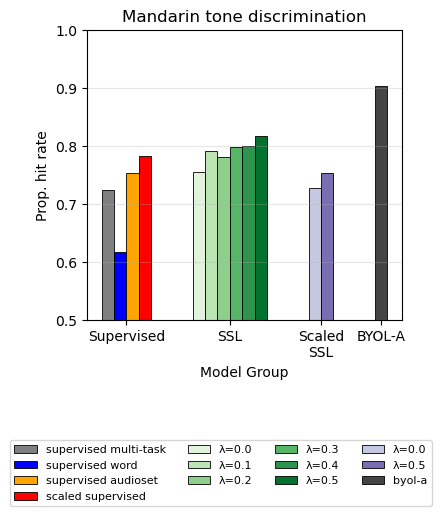

In [17]:
# Get standardized hue order and colors
hue_order = get_standard_hue_order()
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

# Use plot_grouped_bars for the main squared L2 norm plot
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

legend_handles, legend_labels = plot_grouped_bars(
    ax,
    mandarin_tone_df,
    value_col='sqr_l2_judgement',
    title='Mandarin tone discrimination',
    ylabel='Prop. hit rate',
    hue_order=hue_order,
    hue_dict=hue_dict,
)

ax.set_ylim(0.5, 1.0)
ax.grid(axis='y', alpha=0.3, zorder=-1)

# Add legend
if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.1),
        ncol=4,
    )

plt.tight_layout()
plt.show()

## Plot Results - All Metrics Comparison

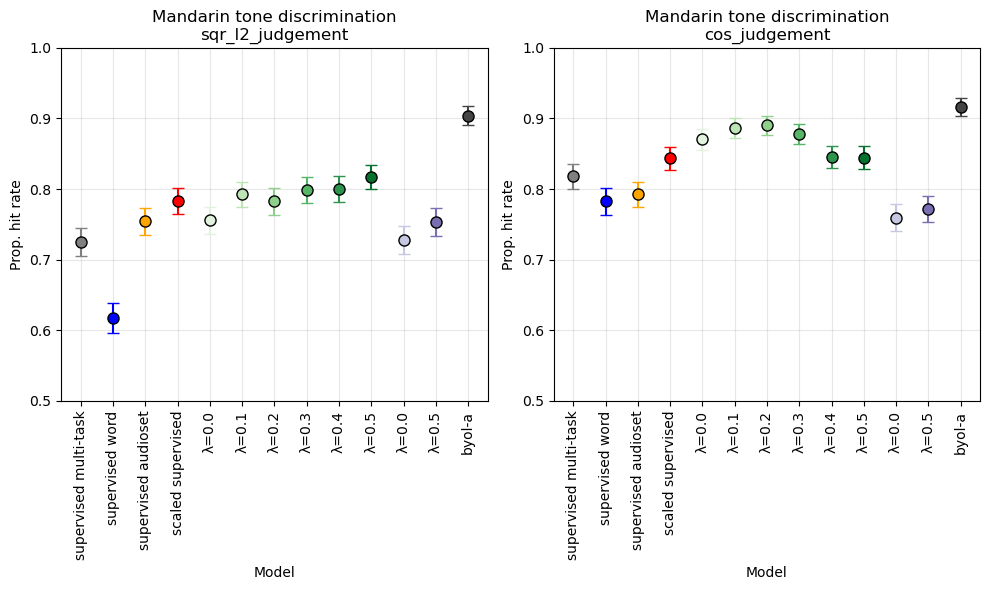

In [20]:
# For comparison across metrics, use errorbar plots with figure_utils styling
fig, axes = plt.subplots(1, 2, figsize=(10, 6), constrained_layout=False)

# Filter to only models we have data for
available_models = mandarin_tone_df['model_name'].unique()
hue_order_filtered = [m for m in hue_order if m in available_models]

# plot mean judgement for each model
for ix, metric in enumerate(["sqr_l2_judgement", "cos_judgement"]):
    for model in hue_order_filtered:
        model_data = mandarin_tone_df[mandarin_tone_df.model_name == model][metric]
        if len(model_data) == 0:
            continue
        mean_val = model_data.mean()
        error = 2 * model_data.std() / np.sqrt(len(model_data))
        
        x_pos = hue_order_filtered.index(model)
        color = hue_dict.get(model, '#444444')
        
        axes[ix].errorbar(
            x_pos,
            mean_val,
            fmt='o',
            yerr=error,
            color=color,
            markeredgecolor="k",
            markersize=8,
            capsize=4,
        )
    
    axes[ix].set_title(f"Mandarin tone discrimination\n{metric}")
    axes[ix].set_ylabel("Prop. hit rate")
    axes[ix].set_xlabel("Model")
    axes[ix].grid(True, alpha=0.3)
    axes[ix].set_ylim(0.5, 1)
    axes[ix].set_xticks(range(len(hue_order_filtered)))
    axes[ix].set_xticklabels([model_label(m) for m in hue_order_filtered], rotation=90, ha='center')

plt.tight_layout()
plt.show()